In [330]:
################## Population Annealing for The TSP Problem ########################

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, permutations

num_replicas = 10
num_betas = 20
beta_schedule = np.linspace(0.1, 5, num_betas)
beta_schedule = np.append(0, beta_schedule)
num_local_moves_per_beta = 100


# Building the graph
cities_code = [0, 1, 2, 3, 4]
distances = [2.24, 3.61, 3.16, 2.24, 2, 3.61, 3.61, 2.24, 4, 2.24]
num_cities = len(cities_code)

def build_Distances_Matrix(distances, cities_code, num_cities):

    graph_Edges = list(combinations(cities_code, 2))
    
    Distances_matrix = np.zeros([num_cities, num_cities])
    for idx, edge in enumerate(graph_Edges):
        Distances_matrix[edge] = distances[idx]
    
    Distances_matrix = Distances_matrix + Distances_matrix.T
    return(Distances_matrix)

Distances_matrix = build_Distances_Matrix(distances, cities_code, num_cities)


tour = [0, 1, 3, 2, 4] # 0-->1-->3--->2-->4--->0

def energy_function(tour, Distances_matrix):
    return(np.sum(Distances_matrix[tour, np.roll(tour, -1)]))


def MCMC_Metropolis_Hastings(entire_system, num_local_moves_per_beta,beta_idx, beta, Distances_matrix, num_cities, num_replicas):

    # we use the insertion proposal: {(1, 2), (2, 3), (3, 4)}---2---> {(1, 4), (4, 3), (3, 2)}
    

    for replica_idx in range(num_replicas):
        tour = entire_system[replica_idx, beta_idx-1,:]
        
        for _ in range(num_local_moves_per_beta):

            # propose a move_idx and insert_idx
            proposal = np.random.choice(np.arange(num_cities, dtype=int), 2, replace=False)
            city_to_insert = tour[proposal[0]]
            
            # remove the city to be inserted elsewhere
            reduced_tour = np.delete(tour, proposal[0])
            
            # insert the proposed city
            tour_proposed = np.insert(reduced_tour, proposal[1], city_to_insert)

            energy_after = energy_function(tour_proposed, Distances_matrix)
            energy_before = energy_function(tour, Distances_matrix)
            
            accept_prop = min(1.0, np.exp(-beta*(energy_after-energy_before)))
            
            if np.random.uniform() < accept_prop:
                entire_system[replica_idx, beta_idx,:] = tour_proposed
            else:
                entire_system[replica_idx, beta_idx,:] = tour

            tour = entire_system[replica_idx, beta_idx,:]

    return(entire_system)




entire_system = np.zeros([num_replicas, len(beta_schedule), len(tour)], dtype=int) # Save the final MCMC state at each beta for each replica.
energy_track = np.zeros([num_replicas, len(beta_schedule)])


#### Apply Population Annealing ####

# random initialization --- beta=0
for replica in range(num_replicas):
    entire_system[replica, 0, :] = np.random.choice(np.arange(num_cities, dtype=int), num_cities,replace=False)
    energy_track[replica, 0] = energy_function(entire_system[replica, 0, :], Distances_matrix)



replica_weight = np.zeros(num_replicas)
for beta_idx in range(1, len(beta_schedule)):

    replica_weight = np.array([np.exp(-(beta_schedule[beta_idx]-beta_schedule[beta_idx-1])*energy_function(replica_tour, Distances_matrix)) for replica_tour in entire_system[:, beta_idx-1, :]])
    
    replica_weight = replica_weight/np.sum(replica_weight) # probability vector across replicas

    # resampling according to replica_weight
    resampled_replicas = np.random.choice(np.arange(num_replicas, dtype=int), num_replicas, p=replica_weight)

    entire_system[:, beta_idx-1, :] = entire_system[resampled_replicas, beta_idx-1, :]
    energy_track[:, beta_idx-1] = energy_track[resampled_replicas, beta_idx-1]

    # apply the M MCMC moves across all replicas
    entire_system = MCMC_Metropolis_Hastings(entire_system, num_local_moves_per_beta,beta_idx, beta_schedule[beta_idx], Distances_matrix, num_cities, num_replicas)


    # energy after the M MCMC moves across all replicas     
    energy_track[:, beta_idx]  = [energy_function(replica_tour, Distances_matrix) for replica_tour in entire_system[:, beta_idx, :]]

    


In [334]:
best_brute_energy = np.inf
best_brute_tour = None

for tour in permutations(range(num_cities)):
    tour = np.array(tour)
    E = energy_function(tour, Distances_matrix)

    if E < best_brute_energy:
        best_brute_energy = E
        best_brute_tour = tour.copy()

print("True optimum tour:", best_brute_tour)
print("True optimum energy:", best_brute_energy)

True optimum tour: [0 1 2 3 4]
True optimum energy: 10.96


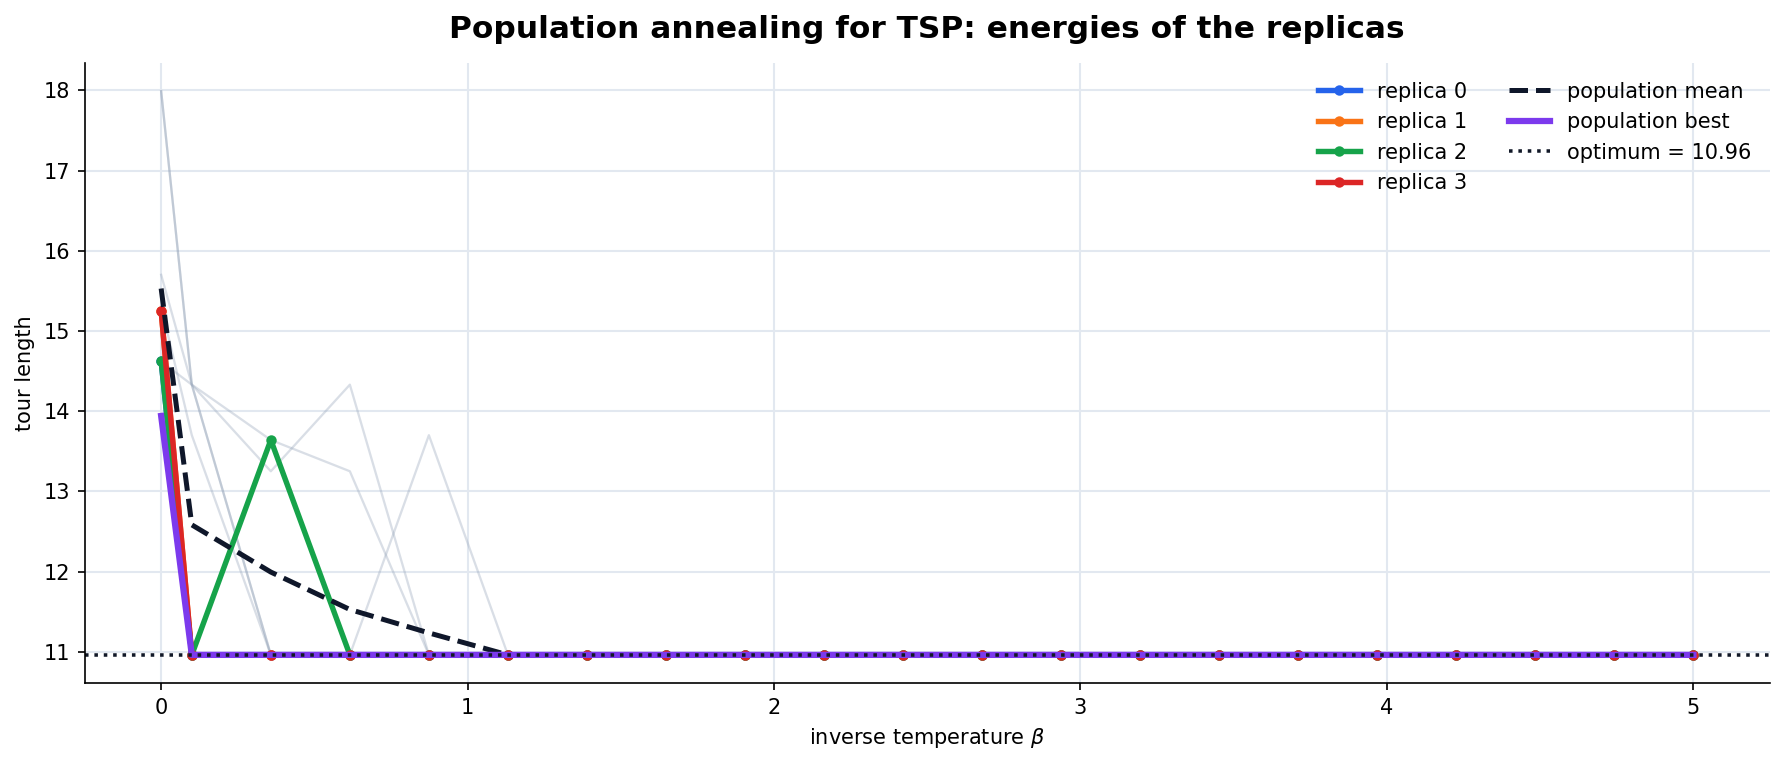

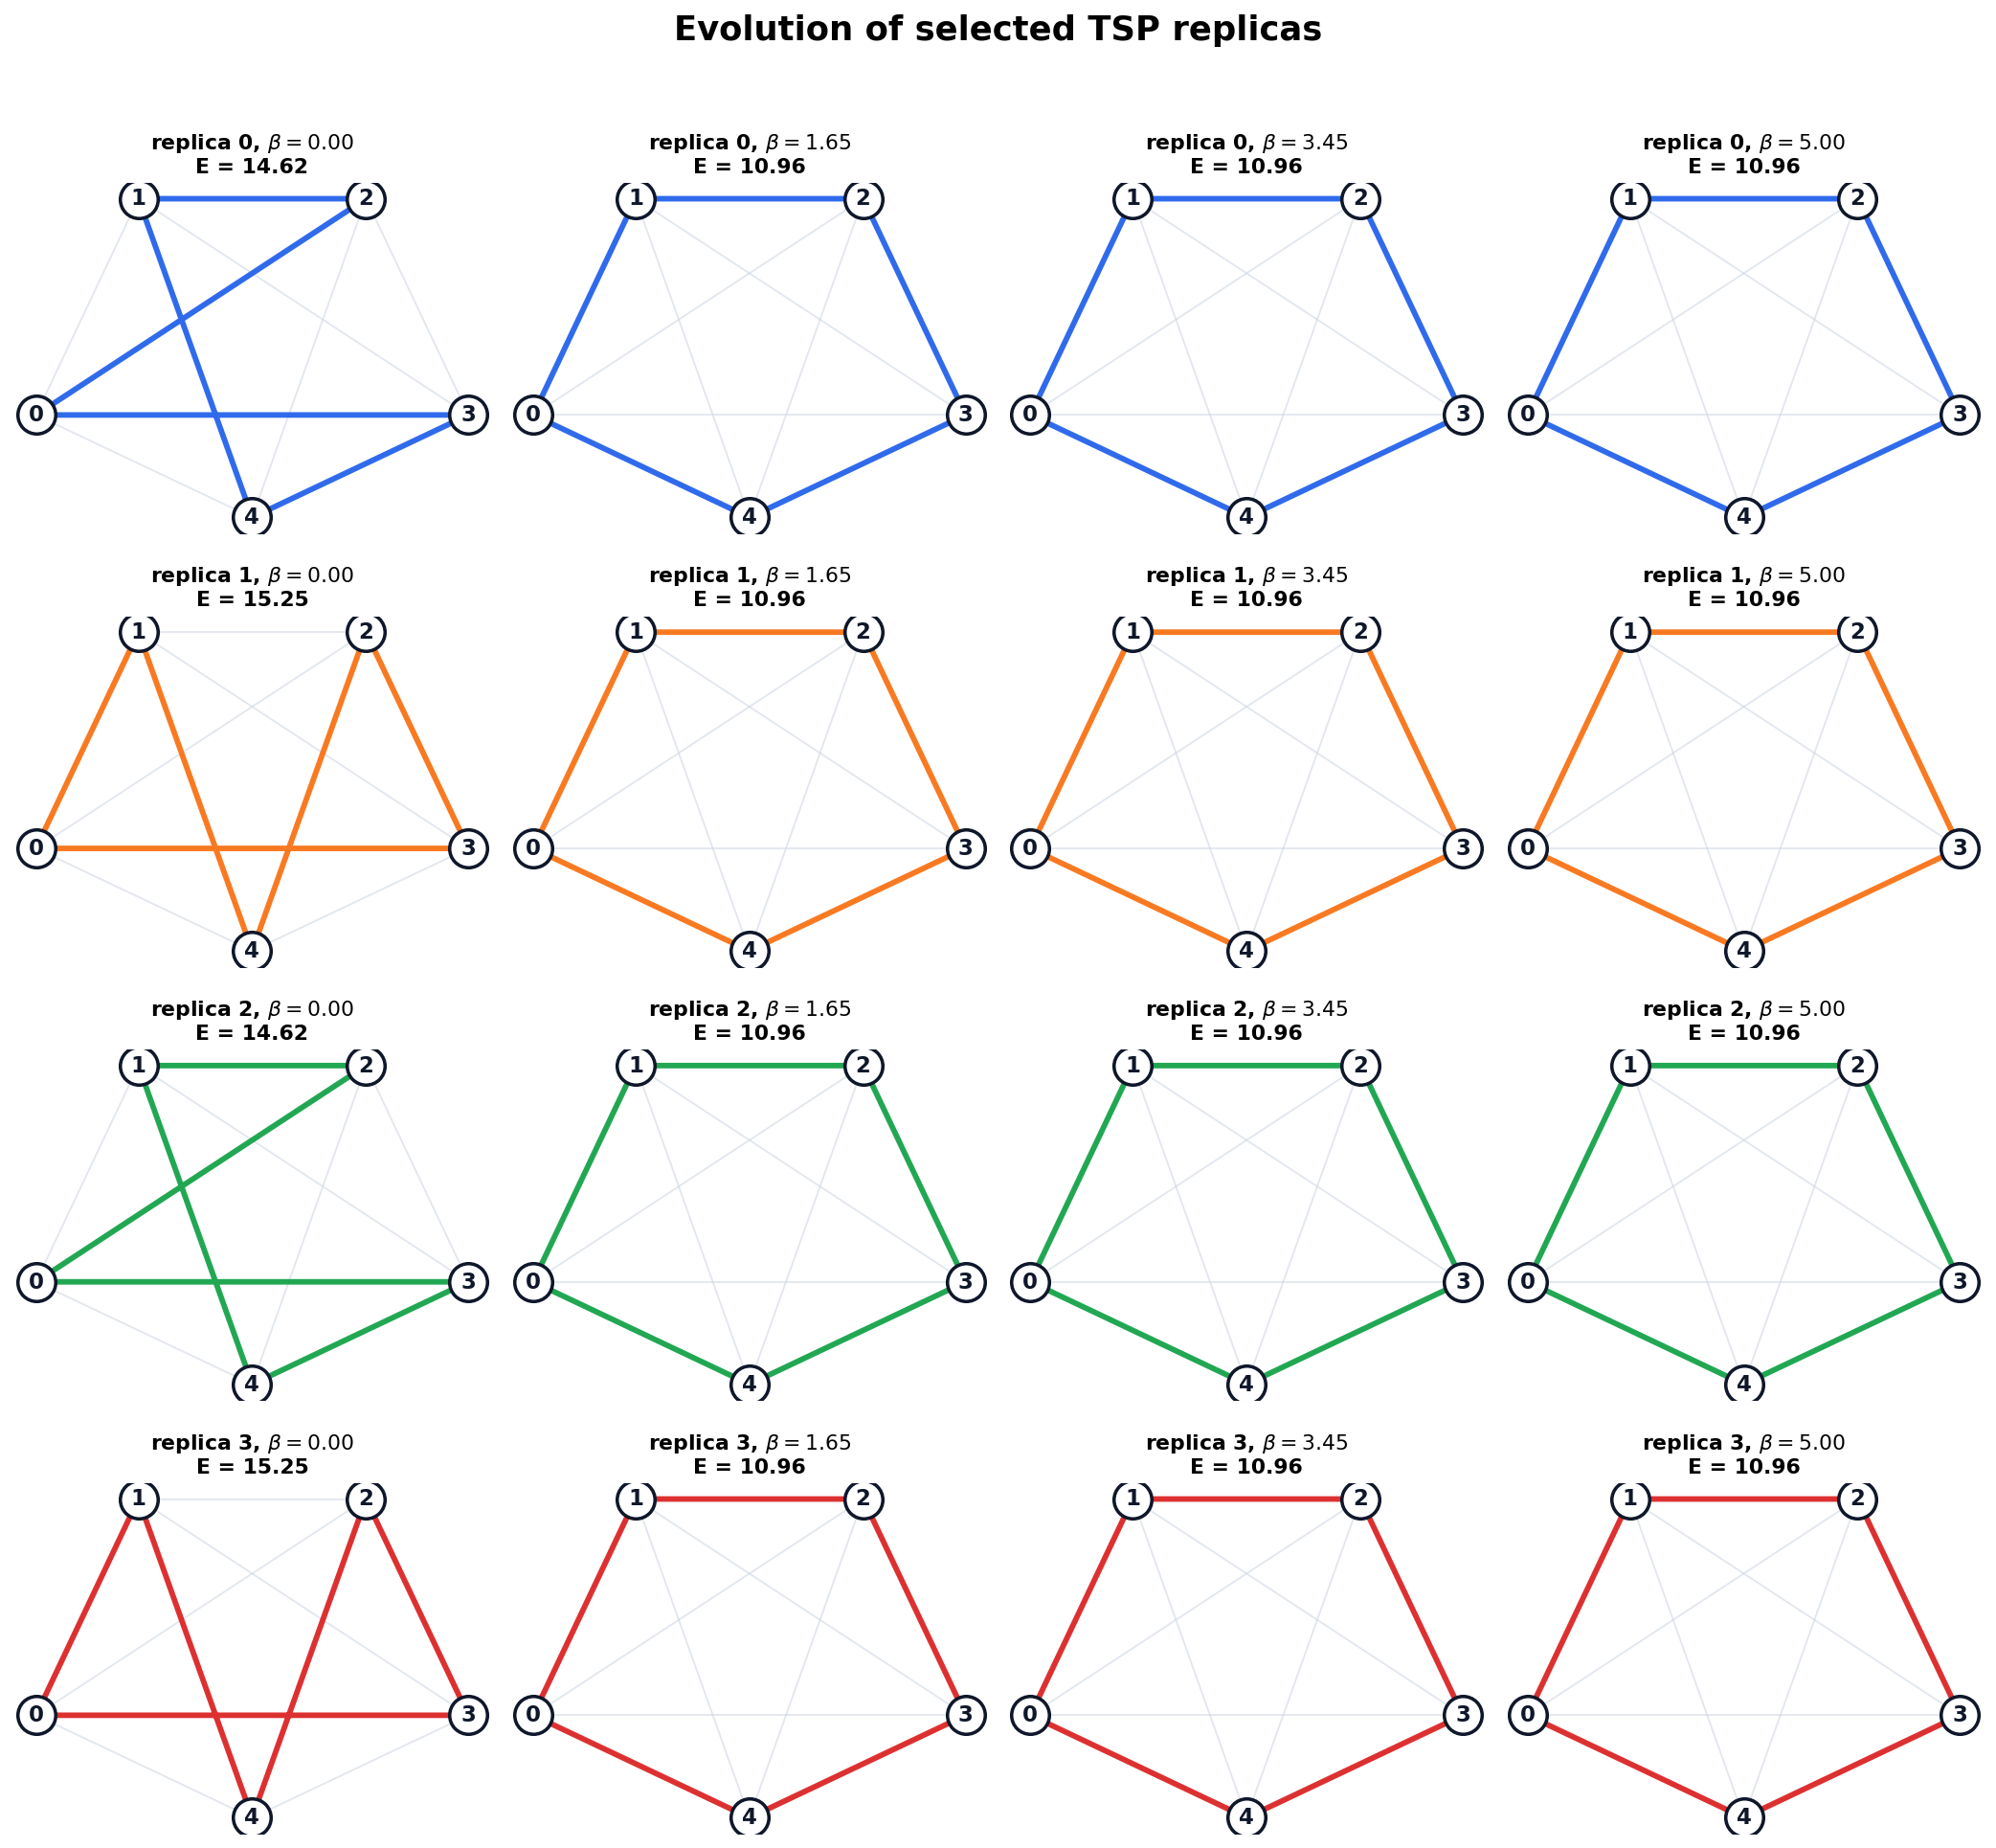

Best final replica: 0
Best final tour: [4 0 1 2 3]
Best final energy: 10.96


In [335]:
################## Beautiful plots: population and replica evolution ########################

city_positions = np.array([
    [0.0, 0.0],
    [0.9, 1.9],
    [2.9, 1.9],
    [3.8, 0.0],
    [1.9, -0.9],
])

def draw_tour(ax, tour, title='', color='#2563eb'):
    tour = np.asarray(tour, dtype=int)
    closed_tour = np.r_[tour, tour[0]]
    xy = city_positions[closed_tour]

    # Draw the complete graph very lightly, then place the current tour on top.
    for i, j in combinations(range(num_cities), 2):
        ax.plot(
            [city_positions[i, 0], city_positions[j, 0]],
            [city_positions[i, 1], city_positions[j, 1]],
            color='#cbd5e1', lw=0.9, alpha=0.55, zorder=0,
        )

    ax.plot(xy[:, 0], xy[:, 1], color=color, lw=2.8, alpha=0.95, zorder=2)
    ax.scatter(city_positions[:, 0], city_positions[:, 1], s=360, color='white', edgecolor='#0f172a', linewidth=1.7, zorder=3)

    for city, (x, y) in enumerate(city_positions):
        ax.text(x, y, str(city), ha='center', va='center', fontsize=11, weight='bold', color='#0f172a', zorder=4)

    ax.set_title(title, fontsize=10.5, weight='bold', pad=5)
    ax.set_aspect('equal')
    ax.axis('off')

best_energy_by_beta = energy_track.min(axis=0)
mean_energy_by_beta = energy_track.mean(axis=0)
final_order = np.argsort(energy_track[:, -1])
selected_replicas = final_order[:min(4, num_replicas)]
selected_colors = ['#2563eb', '#f97316', '#16a34a', '#dc2626']

fig, ax = plt.subplots(figsize=(12, 5.2), dpi=150)
fig.patch.set_facecolor('white')

for replica in range(num_replicas):
    ax.plot(beta_schedule, energy_track[replica], color='#94a3b8', lw=1.1, alpha=0.35)

for color, replica in zip(selected_colors, selected_replicas):
    ax.plot(beta_schedule, energy_track[replica], color=color, lw=2.6, marker='o', markersize=4, label=f'replica {replica}')

ax.plot(beta_schedule, mean_energy_by_beta, color='#0f172a', lw=2.4, linestyle='--', label='population mean')
ax.plot(beta_schedule, best_energy_by_beta, color='#7c3aed', lw=3.0, label='population best')
ax.axhline(best_brute_energy, color='#111827', lw=1.7, linestyle=':', label=f'optimum = {best_brute_energy:.2f}')

ax.set_title('Population annealing for TSP: energies of the replicas', fontsize=15, weight='bold', pad=12)
ax.set_xlabel(r'inverse temperature $\beta$')
ax.set_ylabel('tour length')
ax.grid(True, color='#e2e8f0', linewidth=1)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

snapshot_indices = [0, len(beta_schedule)//3, 2*len(beta_schedule)//3, len(beta_schedule)-1]
snapshot_labels = [fr'$\beta={beta_schedule[idx]:.2f}$' for idx in snapshot_indices]

fig, axes = plt.subplots(len(selected_replicas), len(snapshot_indices), figsize=(14, 3.2 * len(selected_replicas)), dpi=150)
fig.patch.set_facecolor('white')

if len(selected_replicas) == 1:
    axes = np.array([axes])

for row, replica in enumerate(selected_replicas):
    color = selected_colors[row % len(selected_colors)]
    for col, beta_idx in enumerate(snapshot_indices):
        tour = entire_system[replica, beta_idx]
        energy = energy_function(tour, Distances_matrix)
        title = f'replica {replica}, {snapshot_labels[col]}\nE = {energy:.2f}'
        draw_tour(axes[row, col], tour, title=title, color=color)

plt.suptitle('Evolution of selected TSP replicas', fontsize=17, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_replica = np.argmin(energy_track[:, -1])
print('Best final replica:', best_replica)
print('Best final tour:', entire_system[best_replica, -1])
print('Best final energy:', energy_track[best_replica, -1])
